# cNMF in `cellarium-ml`

Stephen Fleming

2026.04.08

The `cellarium-ml` project:
https://github.com/cellarium-ai/cellarium-ml

The specific implementation of cNMF we are actively working on:
https://github.com/cellarium-ai/cellarium-ml/pull/196

## What's in this notebook

Demo of how to run cNMF on a dataset.

## Installation of `cellarium-ml`

NOTE: You will need to use the `nmf_sf-amortized` branch of `cellarium-ml` on github

This can be accomplished by doing the following (here the example uses a conda environment to keep things separate):

```bash
(base) $ conda create -n cellarium python=3.10
(base) $ conda activate cellarium
(cellarium) $ pip install git+https://github.com/cellarium-ai/cellarium-ml.git@nmf_sf-amortized
```

Then ensure jupyter is pointing at your cellarium environment, either by installing jupyter inside the cellarium conda env, or by installing ipykernel there and pointing to that kernel from jupyter running in some other environment. If this is not clear, try

```bash
(cellarium) $ pip install jupyter
(cellarium) $ jupyter notebook
```

If the imports in the next section work, you are all set.

## Imports

In [1]:
import cellarium.ml.preprocessing
import cellarium.ml.data
import cellarium.ml.transforms
import cellarium.ml.api
import cellarium.ml.models

import lightning.pytorch as pl
import numpy as np
import pandas as pd
import torch

/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
%load_ext autoreload
%autoreload 2

# Data

Specify a local h5ad file as your dataset.  Technically you can specify an http or gs filepath if you want, but training will be slower if it has to stream the file from somewhere that's not your machine.

NOTE: the only requirement is that all h5ad files must have the same `adata.var_names` if you have several h5ad files. (There are ways to relax this requirement but for now let's say it's required.)

Here I will demonstrate grabbing a file from a google bucket.

```bash
$ gsutil cp gs://broad-bican-cellarium-file-system/SMRI/glutamatergic_L5IT/L5IT_fold1.h5ad /dsde/working/sfleming/bican/
```

In [3]:
# specify any h5ad file data: can be multiple files in a list

h5ad_paths = [
    "/Users/sfleming/Documents/Projects/bican/cnmf/test_data/haley_bipolar_amygdala_OPCs_and_COPs.h5ad",
]

## Cellarium data setup

For this demo we are using the python API for cellarium.  This involves some boilerplate, so this is the boilerplate.

It's also possible to use command line versions of these tools.

In [4]:
h5ad_paths

['/Users/sfleming/Documents/Projects/bican/cnmf/test_data/haley_bipolar_amygdala_OPCs_and_COPs.h5ad']

(For remote files over the internet, this next cell can take a minute.)

In [ ]:
# this sets up the data in a datamodule that cellarium needs

def get_datamodule(batch_size=4096, shuffle=True, train_size=1.0):

    datamodule = cellarium.ml.CellariumAnnDataDataModule(
        dadc=cellarium.ml.data.DistributedAnnDataCollection(
            filenames=h5ad_paths,
            limits=np.cumsum(cellarium.ml.api.get_h5ad_files_n_cells(h5ad_paths))  # this looks up how many cells are in each file
        ),
        batch_keys={
            "x_ng": cellarium.ml.utilities.data.AnnDataField(
                attr="X", 
                convert_fn=cellarium.ml.utilities.data.densify,
            ),
            "var_names_g": cellarium.ml.utilities.data.AnnDataField(attr="var_names"),
            "obs_names_n": cellarium.ml.utilities.data.AnnDataField(attr="obs_names"),
        },
        batch_size=batch_size,
        shuffle=shuffle,
        train_size=train_size,
        prefetch_factor=1,
        num_workers=0,
    )

    datamodule.setup(stage="fit")
    return datamodule

# Highly variable genes

The first step in cNMF is to choose which genes are involved in the computation.  If you already know this, you can skip this section.

If you want to use `cellarium-ml` to compute highly variable genes (like for a 100M cell dataset), this is how.

## Run `seurat_v3` flavor of highly variable gene selection

You have the option to use a `batch_key` as well, as in scanpy. Here we will not use a `batch_key`.

In [6]:
# set up the model that will be used to compute mean and var of each gene

datamodule = get_datamodule()

n_top_genes = 2000
flavor = "seurat_v3"  # could also choose "seurat_v3_paper" but these are identical with no batch_key
output_path = "./cellarium_hvg.csv"  # an output file will be written here

hvg_module = cellarium.ml.CellariumModule(
    transforms=[cellarium.ml.transforms.Densify()],
    model=cellarium.ml.models.HVGSeuratV3(
        var_names_g=datamodule.dadc.schema.attr_values["var"].index.to_numpy(),
        n_top_genes=n_top_genes,
        flavor=flavor,
        n_batch=1,
        use_batch_key=False,
        output_path=output_path,
    )
)

trainer = pl.Trainer(
    accelerator="cpu",
    devices=1,
    max_epochs=2,  # HVGSeuratV3 happens in two passes
    default_root_dir="tmp/hvg",
)
trainer.fit(hvg_module, datamodule)

Reading n_obs from h5ad files: 100%|██████████| 1/1 [00:00<00:00, 25575.02file/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Epoch 1: 100%|██████████| 32/32 [01:25<00:00,  0.38it/s, v_num=7]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 32/32 [01:25<00:00,  0.37it/s, v_num=7]


In [6]:
output_path = "./cellarium_hvg.csv"

In [7]:
# the model writes an output csv with the highly variable genes

hvg_df = pd.read_csv(output_path.replace(".csv", "__hvg_only.csv"), index_col=0)
hvg_df

,highly_variable_rank,variances_norm,highly_variable
gene,,,
FRMD4A,0.0,35.114753,True
AC011287.1,1.0,19.797082,True
HSPH1,2.0,18.799163,True
ST18,3.0,12.281309,True
RASGEF1B,4.0,11.566115,True
...,...,...,...
RNF217,1995.0,1.146049,True
CACNA1E,1996.0,1.145943,True
AL591885.1,1997.0,1.145710,True


In [8]:
# the highly variable genes

hvg_var_names_g = hvg_df.index.to_numpy()
hvg_var_names_g

array(['FRMD4A', 'AC011287.1', 'HSPH1', ..., 'AL591885.1', 'CNIH3',
       'GSTCD'], dtype=object)

You could also use your own pre-computed list of highly variable genes.  Just set `hvg_var_names_g` equal to your own numpy array here.

## Compute per-gene std of raw values

Per-gene raw count standard deviations are used as a preprocessing transformation in cNMF.

In `cellarium-ml`, this computation is separate from highly-variable gene computation.

In [9]:
len(hvg_var_names_g)

2000

In [11]:
# set up the model that will be used to compute mean and var of each gene

datamodule = get_datamodule()

raw_onepass_module = cellarium.ml.CellariumModule(
    transforms=[cellarium.ml.transforms.Densify()],
    model=cellarium.ml.models.OnePassMeanVarStd(
        var_names_g=datamodule.dadc.schema.attr_values["var"].index.to_numpy(),
    )
)

trainer = pl.Trainer(
    accelerator="cpu",
    devices=1,
    max_epochs=1,
    default_root_dir="tmp/onepass",
)
trainer.fit(raw_onepass_module, datamodule)

std = pd.Series(raw_onepass_module.model.std_g + 1e-5, index=datamodule.dadc.schema.attr_values["var"].index.to_numpy())

Reading n_obs from h5ad files: 100%|██████████| 1/1 [00:00<00:00, 27060.03file/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 32/32 [00:45<00:00,  0.70it/s, v_num=35]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 32/32 [00:45<00:00,  0.70it/s, v_num=35]


In [12]:
std

A1BG              0.035205
A1BG-AS1          0.046025
A1CF              0.062942
A2M               0.369948
A2M-AS1           0.192276
                    ...   
ZZEF1             0.861115
ZZZ3              2.046591
hsa-mir-548d-2    0.008841
snoR1             0.054872
snoZ196           0.010459
Length: 32925, dtype: float32

In [14]:
std.to_csv("./cellarium_gene_std.csv")

In [19]:
std = pd.read_csv("./cellarium_gene_std.csv", index_col=0)['0'].astype(np.float32)
std

A1BG              0.035205
A1BG-AS1          0.046025
A1CF              0.062942
A2M               0.369948
A2M-AS1           0.192276
                    ...   
ZZEF1             0.861115
ZZZ3              2.046591
hsa-mir-548d-2    0.008841
snoR1             0.054872
snoZ196           0.010459
Name: 0, Length: 32925, dtype: float32

# cNMF

## Run NMF

Set things up to run cNMF in cellarium.

In [50]:
# user's choice for the number of components: must input a python list

# k_values = [18]
k_values = list(range(3, 31))

In [51]:
# user's choice for the number of NMF replicates that should go into consensus

nmf_replicates = 200

In [53]:
import gc

try:
    del datamodule
except:
    pass
try:
    del hvg_module
except:
    pass
try:
    del raw_onepass_module
except:
    pass
try:
    del trainer
except:
    pass
try:
    del nmf_module
except:
    pass
try:
    del trainer_nmf
except:
    pass

gc.collect()

1932

In [ ]:
# train a series of NMF models using a for-loop over k

datamodule = get_datamodule()

import torch._dynamo
torch._dynamo.config.suppress_errors = True
import time

t0 = time.time()

for i, k in enumerate(k_values):
    print(f"Training NMF model with k={k} ({i+1}/{len(k_values)})...")

    nmf_model = cellarium.ml.models.OnlineNonNegativeMatrixFactorization(
        var_names_g=hvg_var_names_g,
        k_values=[k],
        r=nmf_replicates,
        algorithm="nmf_torch_hals",  # this is the algorithm that best reproduced the McCarroll results
        n_cells_total=len(datamodule.dadc),
    )

    nmf_module = cellarium.ml.CellariumModule(
        cpu_transforms=[
            cellarium.ml.transforms.Filter(filter_list=hvg_var_names_g),
        ],
        transforms=[
            cellarium.ml.transforms.Densify(),
            cellarium.ml.transforms.DivideByScale(
                scale_g=torch.as_tensor(std.to_numpy()),
                var_names_g=std.index.to_numpy(),
                eps=1e-4,
            ),
        ],
        model=nmf_model,
    )

    trainer_nmf = pl.Trainer(
        accelerator="cpu",
        devices=1,
        max_epochs=10,  # this is up for debate, but empirically 10 seems to be enough
        default_root_dir=f"tmp/nmf_{k}",
    )

    pl.seed_everything(0)  # not required but helps make this notebook reproducible
    t_i = time.time()
    trainer_nmf.fit(nmf_module, datamodule)
    print(f"Run for k={k} took {(time.time() - t_i) / 60:.2f} mins")

print(f"Full run took {(time.time() - t0) / 60:.2f} mins")

Reading n_obs from h5ad files: 100%|██████████| 1/1 [00:00<00:00, 13706.88file/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 0

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 32/32 [01:49<00:00,  0.29it/s, v_num=52]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 32/32 [01:49<00:00,  0.29it/s, v_num=52]
Full run took 17.86 mins


In [25]:
# see the shape of the NMF gene programs that have been inferred: [replicates, k, genes]

for k in nmf_model.k_values:
    print(getattr(nmf_model, f"D_{k}_rkg").shape)

torch.Size([50, 3, 2000])
torch.Size([50, 4, 2000])
torch.Size([50, 5, 2000])


In [26]:
k_values2 = list(range(6, 11))

datamodule = get_datamodule()

nmf_model2 = cellarium.ml.models.OnlineNonNegativeMatrixFactorization(
    var_names_g=hvg_var_names_g,
    k_values=k_values2,
    r=nmf_replicates,
    algorithm="nmf_torch_hals",  # this is the algorithm that best reproduced the McCarroll results
    n_cells_total=len(datamodule.dadc),
)

nmf_module2 = cellarium.ml.CellariumModule(
    cpu_transforms=[
        cellarium.ml.transforms.Filter(filter_list=hvg_var_names_g),
    ],
    transforms=[
        cellarium.ml.transforms.Densify(),
        cellarium.ml.transforms.DivideByScale(
            scale_g=torch.as_tensor(std.to_numpy()),
            var_names_g=std.index.to_numpy(),
            eps=1e-4,
        ),
    ],
    model=nmf_model2,
)

trainer_nmf2 = pl.Trainer(
    accelerator="cpu",
    devices=1,
    max_epochs=10,  # this is up for debate, but empirically 10 seems to be enough
    default_root_dir="tmp/nmf2",
)

import torch._dynamo
torch._dynamo.config.suppress_errors = True
import time

pl.seed_everything(0)  # not required but helps make this notebook reproducible

t = time.time()
trainer_nmf2.fit(nmf_module2, datamodule)
print(f"Full run took {(time.time() - t) / 60:.2f} mins")

Reading n_obs from h5ad files: 100%|██████████| 1/1 [00:00<00:00, 8192.00file/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 0

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 32/32 [02:41<00:00,  0.20it/s, v_num=2]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 32/32 [02:43<00:00,  0.20it/s, v_num=2]
Full run took 28.33 mins


## Set up to explore outputs

We have a helper class that facilitates downstream analysis steps. Here we instantiate it and use it to get various outputs.

In [27]:
from cellarium.ml.models.nmf import NMFOutput

In [29]:
# if you've trained several models due to memory constraints, they can be combined like this:

nmf_output = NMFOutput.from_checkpoints(
    checkpoint_paths=[
        "tmp/nmf/NMF.ckpt",
        "tmp/nmf2/NMF.ckpt",
    ],
    datamodule=datamodule,
)

100%|██████████| 2/2 [00:02<00:00,  1.08s/it]


In [ ]:
# if you've managed to fit everything into one model, you can also just do this, but the above works

# nmf_output = NMFOutput(
#     nmf_module=nmf_module,
#     datamodule=datamodule,
# )

In [30]:
nmf_output

NMFOutput(
    nmf_module=CellariumModule(pipeline = CellariumPipeline(
          (0): Filter(filter_list=['FRMD4A' 'AC011287.1' 'HSPH1' ... 'AL591885.1' 'CNIH3' 'GSTCD'], ordering=True, allow_missing=False)
          (1): Densify()
          (2): DivideByScale(scale_g=tensor([0.0352, 0.0460, 0.0629,  ..., 0.0088, 0.0549, 0.0105]), var_names_g=['A1BG' 'A1BG-AS1' 'A1CF' ... 'hsa-mir-548d-2' 'snoR1' 'snoZ196'], eps=0.0001)
          (3): OnlineNonNegativeMatrixFactorization(
            (transform__filter_to_hvgs): Filter(filter_list=['FRMD4A' 'AC011287.1' 'HSPH1' ... 'AL591885.1' 'CNIH3' 'GSTCD'], ordering=True, allow_missing=False)
          )
        )),
    datamodule={Train dataloader: size=32}
        {Validation dataloader: size=0}
        {Test dataloader: None}
        {Predict dataloader: size=32}
)
with consensus []

## Create k-selection plot

This is what Kotliar cNMF would produce with default values for `local_neighborhood_size=0.3` and `density_threshold=0.5`

cellarium.ml.models.nmf - INFO - Computing consensus factors with default hyperparameters...
cellarium.ml.models.nmf - INFO - Calculating reconstruction error (requires an entire pass through the data)...


100%|██████████| 32/32 [01:19<00:00,  2.47s/it]


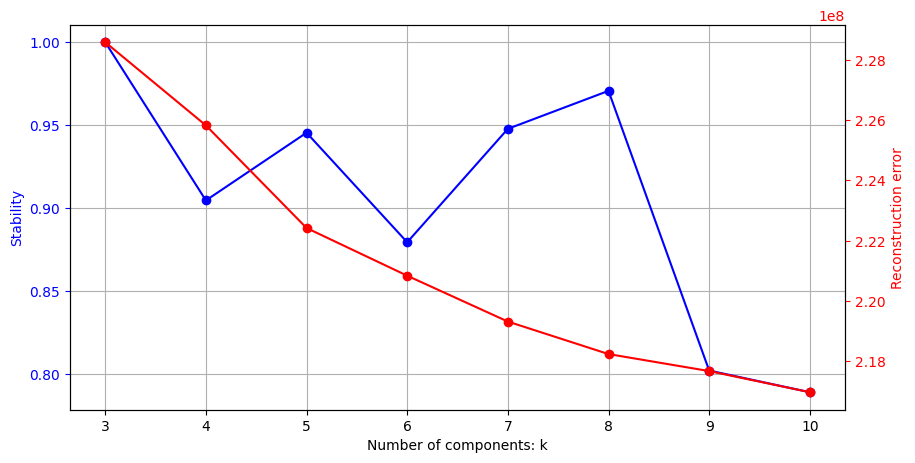

In [35]:
nmf_output.default_k_selection_plot()

This is a new version of this plot which I've invented... it tries to maximize stability for each `k` by separately choosing `density_threshold` values that maximize stability for that `k`. This plot, in my opinion, better reflects which `k` you should choose, because after you choose `k` you're going to optimize your `density_threshold` choice. But I've found that these almost always look pretty similar, and the maximal-stability version takes longer to compute.

cellarium.ml.models.nmf - INFO - Computing consensus factors, searching for best density thresholds...


cellarium.ml.models.nmf - WARNING - Unable to find local minima in k=3 density histogram... 'fast' mode will fall back to 'exhaustive'


cellarium.ml.models.nmf - WARNING - Unable to find local minima in k=4 density histogram... 'fast' mode will fall back to 'exhaustive'


100%|██████████| 8/8 [00:26<00:00,  3.37s/it]

cellarium.ml.models.nmf - INFO - Computing reconstruction errors...



100%|██████████| 32/32 [01:23<00:00,  2.61s/it]


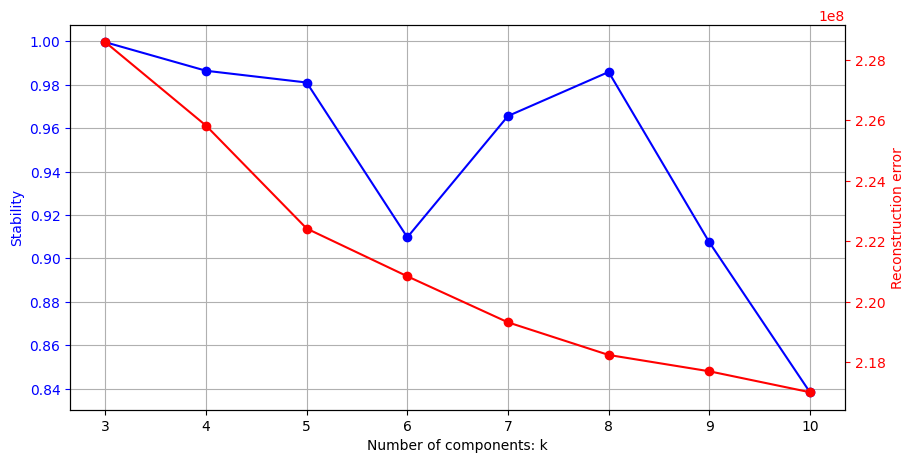

In [36]:
nmf_output.maximal_stability_k_selection_plot()

Here is where you manually choose the best `k` value:

In [37]:
best_k = 8

In [38]:
# you can look up the "best" density_threshold value this way if you ran the maximal-stability thing above

nmf_output.consensus[best_k]['density_threshold']

0.055

In [39]:
# %%time

# # this is how you manually compute consensus factors with specific parameter values

# nmf_output.compute_consensus_factors(k_values=[18], density_threshold=0.145, local_neighborhood_size=0.3)

Here is where you create a clustermap plot and the histogram of neighbor distances.

If you choose `density_threshold=None` this will use whatever value has been computed last for the `compute_consensus_factors()` calculation for that `k`. (This runs automatically under the hood when you create the k-selection plots above.)

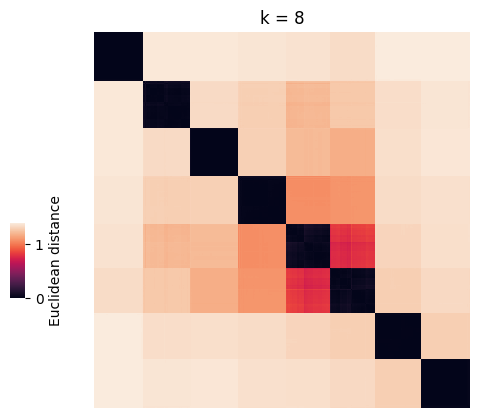

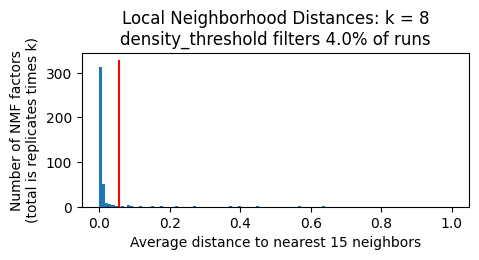

In [40]:
nmf_output.plot_clustermap(k=best_k, density_threshold=None)
# None will use whatever value ran last. Some other value will re-compute consensus give that threshold.

## Compute per-cell loadings

In [41]:
best_k

8

The loadings of each factor, computed for each cell.

In [42]:
# get per-cell factor loadings using the best k: this takes time
# `normalize` controls whether the per-cell loadings sum to 1

df = nmf_output.compute_loadings(k=best_k, normalize=False)

100%|██████████| 32/32 [00:42<00:00,  1.33s/it]


In [43]:
df.shape

(128203, 8)

In [44]:
df

,0,1,2,3,4,5,6,7
V7_rxn5_CGACTGGTCCAACCGG,0.000000,0.000000,0.000000,1512.415649,53.091030,0.000000,576.284119,0.000000
BA46_09-18-2019_rxn8_GCACATATCTGAATGC,7.280920,10.026712,4.747485,39.536819,0.000000,0.000000,0.000000,139.170532
BA46_08-27-2019_rxn2_CACGAATCAAGAGGCT,84.301682,12.041688,170.805191,77.608185,5.277846,153.000397,21.335415,6.253713
SMRI_V6_rxn2_AAAGTGAAGTCACTGT,0.000000,6.909352,25.266212,32.076408,6.674868,0.000000,0.709991,189.962296
V8_rxn1_GTGTTATAGCCTGGTG,32.864517,45.092232,210.821838,860.259705,0.000000,21.265621,0.000000,327.283264
...,...,...,...,...,...,...,...,...
V8_rxn1_GCGCTCAAGGTTCGCG,0.000000,0.000000,23.365210,243.609497,9.113991,0.000000,0.000000,51.941559
SMRI_V13_rxn5_CCGCAAGCAAAGCTCT,3.742233,16.359758,23.762884,125.859589,4.405230,1.611970,0.000000,165.630615
SMRI_V6_rxn8_CTAGACATCGCCATAA,1.960801,0.000000,0.000000,8.715476,0.531710,0.000000,46.936142,4.199218
BA46_09-22-2021_rxn6_CTCCTTTAGCTGTTCA,9.741224,45.243252,37.084087,181.593674,0.000000,0.000000,5.727439,437.299774


### Save cell loadings

In [94]:
# cell_loading_file = "your_cell_loadings_filename_here.txt"
# df.to_csv(cell_loading_file, header=True, index=True, sep='\t')
# cell_loading_file

## Access consensus gene programs

In [45]:
# the consensus gene programs are found here

nmf_output.consensus[best_k]['consensus_D_kg'].shape

torch.Size([8, 2000])

In [46]:
# make this into a labeled dataframe

df_gene = pd.DataFrame(data=nmf_output.consensus[best_k]['consensus_D_kg'].t().numpy(), index=hvg_var_names_g)
df_gene

,0,1,2,3,4,5,6,7
FRMD4A,0.000000,0.006929,0.000000,0.000006,0.000000,0.000104,0.000000,0.000000
AC011287.1,0.000100,0.000000,0.000000,0.000089,0.000065,0.000684,0.000121,0.000194
HSPH1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015771,0.000000
ST18,0.000020,0.005995,0.000000,0.000000,0.000000,0.000000,0.000273,0.000000
RASGEF1B,0.000000,0.006567,0.000000,0.000000,0.000035,0.000039,0.000308,0.000130
...,...,...,...,...,...,...,...,...
RNF217,0.000426,0.000256,0.000989,0.000898,0.000000,0.000204,0.000349,0.001088
CACNA1E,0.000890,0.001341,0.000000,0.000300,0.000000,0.000661,0.000000,0.001685
AL591885.1,0.000252,0.000089,0.000000,0.000898,0.000000,0.000000,0.000000,0.001133
CNIH3,0.000318,0.000185,0.000523,0.001252,0.000010,0.000115,0.000060,0.001401


### Save gene programs

In [98]:
# gene_programs_file = "your_consensus_gene_program_filename_here.txt"
# df_gene.to_csv(gene_programs_file, header=True, index=True, sep='\t')

Here was my old check to see if one of these programs overlapped strongly with the McCarroll special program.

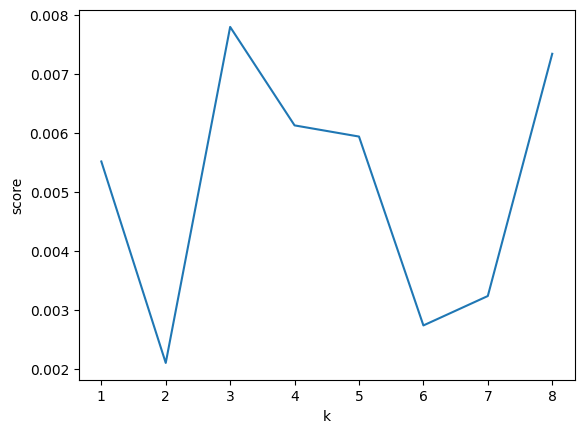

3

In [49]:
import matplotlib.pyplot as plt

vals = df_gene.loc[
    ['DCDC1', 'PRKCH', 'RFC3', 
    #  'ZBTB20', 
     'GPC5', 'PPARG', 
    #  'DGKG', 
    #  'FHIT', 
     'NEAT1', 'SYN3', 
    #  'CDHR3', 
     'SPAG16', 
     'LINC01483', 'LINC01481']
].sum(axis=0)
vals.plot()
plt.xticks(range(best_k), labels=range(1, best_k + 1))
plt.xlabel('k')
plt.ylabel('score')
plt.show()

probable_program = vals.idxmax()
probable_program + 1